In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cicidscollection/cic-collection.parquet


In [3]:
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score, f1_score, accuracy_score
from fastcore.basics import *
from fastcore.parallel import *
from os import cpu_count
import pandas as pd

In [4]:
df = pd.read_parquet('/kaggle/input/cicidscollection/cic-collection.parquet')
df = df.drop(columns='Label')


df['ClassLabel'].unique()

array(['Benign', 'Botnet', 'Bruteforce', 'DoS', 'DDoS', 'Infiltration',
       'Portscan', 'Webattack'], dtype=object)

In [5]:
feature_info = pd.DataFrame({
    'Feature Name': df.columns,
    'Data Type': df.dtypes
})

# Map data types to categories (e.g., text, number)
feature_info['Type Category'] = feature_info['Data Type'].apply(lambda x: 'Text' if x == 'object' else 'Number')

# Add your additional column to the table

# Display the resulting table
print(feature_info)

# Save to a CSV file
feature_info.to_csv('feature_info.csv', index=False)

                                      Feature Name Data Type Type Category
Flow Duration                        Flow Duration     int64        Number
Total Fwd Packets                Total Fwd Packets     int32        Number
Total Backward Packets      Total Backward Packets     int32        Number
Fwd Packets Length Total  Fwd Packets Length Total   float64        Number
Bwd Packets Length Total  Bwd Packets Length Total   float64        Number
Fwd Packet Length Max        Fwd Packet Length Max   float64        Number
Fwd Packet Length Mean      Fwd Packet Length Mean   float32        Number
Fwd Packet Length Std        Fwd Packet Length Std   float32        Number
Bwd Packet Length Max        Bwd Packet Length Max   float64        Number
Bwd Packet Length Mean      Bwd Packet Length Mean   float32        Number
Bwd Packet Length Std        Bwd Packet Length Std   float32        Number
Flow Bytes/s                          Flow Bytes/s   float64        Number
Flow Packets/s           

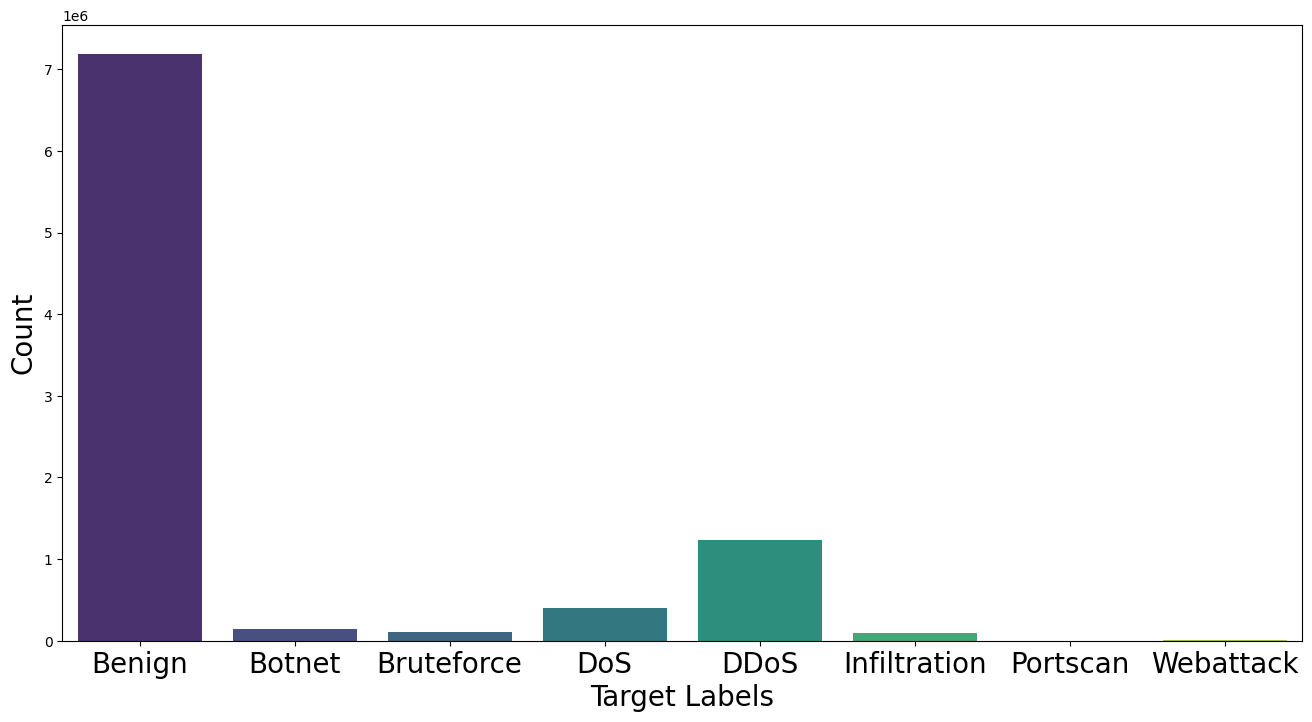

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a larger and clearer figure
plt.figure(figsize=(16, 8))

# Distribution of the target variable
sns.countplot(x='ClassLabel', data=df, palette='viridis')

# Set title and labels
#plt.title('Distribution of the Target Labels', fontsize=16)
plt.xlabel('Target Labels', fontsize=20)
plt.ylabel('Count', fontsize=20)

# Increase the font size of x-axis tick labels
plt.xticks(fontsize=20)  # Adjust the font size according to your preference

plt.savefig('Distribution_target_variables.jpg')
# Show the plot
plt.show()

In [7]:
df.ClassLabel.value_counts()

ClassLabel
Benign          7186189
DDoS            1234729
DoS              397344
Botnet           145968
Bruteforce       103244
Infiltration      94857
Webattack          2995
Portscan           2255
Name: count, dtype: int64

In [8]:

# List of labels and their corresponding counts
labels_and_counts = {
    'Benign': 7186189,
    'DDoS': 1234729,
    'DoS': 397344,
    'Botnet': 145968,
    'Bruteforce': 103244,
    'Infiltration': 94857,
    'Webattack': 2995,
    'Portscan': 2255
}

# Check if rows with each label are unique
for label, count in labels_and_counts.items():
    rows_with_label = df[df['ClassLabel'] == label]

    if not rows_with_label.duplicated().any():
        print(f"All {count} rows with label '{label}' are unique.")
    else:
        print(f"There are duplicates in {count} rows with label '{label}'.")
        print(rows_with_label[rows_with_label.duplicated()])
    print("="*50)

There are duplicates in 7186189 rows with label 'Benign'.
         Flow Duration  Total Fwd Packets  Total Backward Packets  \
321783               1                  2                       0   
346078               2                  3                       0   
361731               2                  1                       1   
366568               4                  2                       0   
369416               3                  3                       0   
...                ...                ...                     ...   
9030704              1                  3                       0   
9036659            158                  1                       1   
9111903            644                  1                       1   
9134426            428                  1                       1   
9163553             11                  2                       1   

         Fwd Packets Length Total  Bwd Packets Length Total  \
321783                       12.0                 

In [9]:
df.drop_duplicates(subset=df.columns[:-1], keep='first')
df.shape

(9167581, 58)

In [10]:
# List of labels to keep
labels_to_keep = ['Benign', 'DDoS', 'Bruteforce', 'Botnet']

# Filter the DataFrame to only keep rows with specified labels
df = df[df['ClassLabel'].isin(labels_to_keep)]

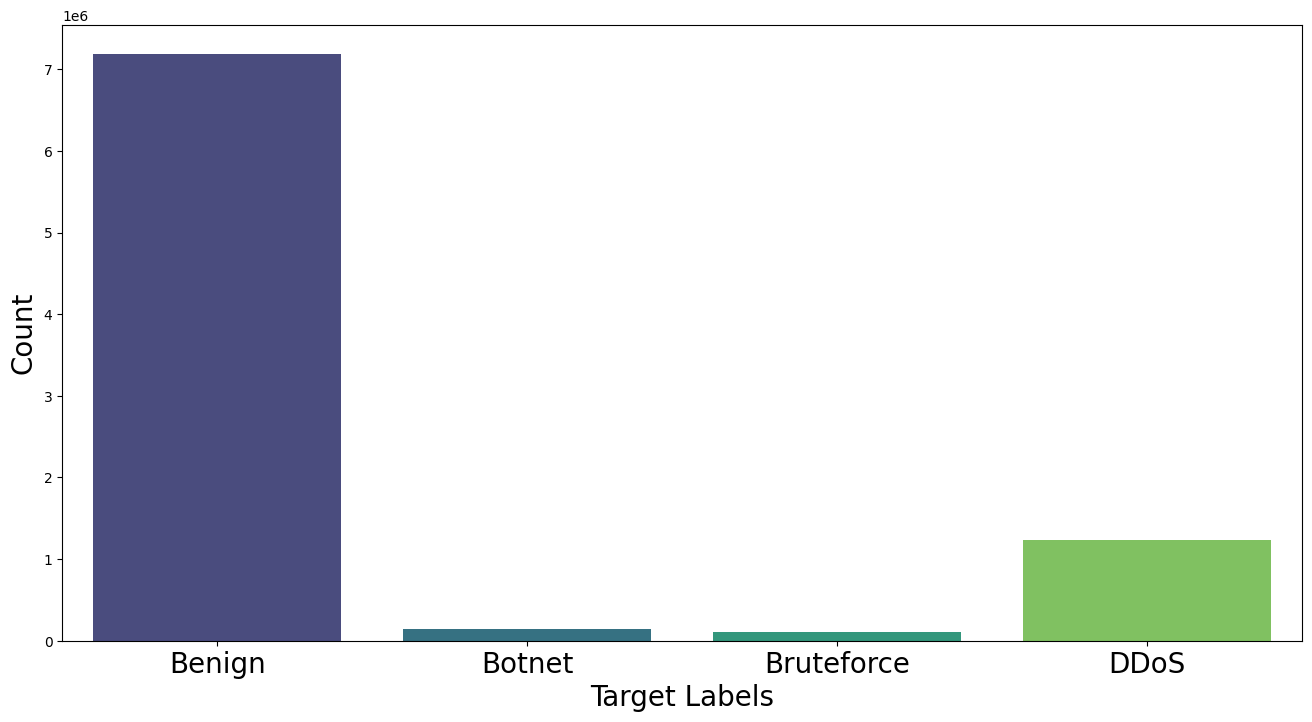

In [11]:
# Create a larger and clearer figure
plt.figure(figsize=(16, 8))

# Distribution of the target variable
sns.countplot(x='ClassLabel', data=df, palette='viridis')

# Set title and labels
#plt.title('Distribution of the Target Labels', fontsize=16)
plt.xlabel('Target Labels', fontsize=20)
plt.ylabel('Count', fontsize=20)

# Increase the font size of x-axis tick labels
plt.xticks(fontsize=20)  # Adjust the font size according to your preference

plt.savefig('Target_distribution_after_drop.png')
# Show the plot
plt.show()


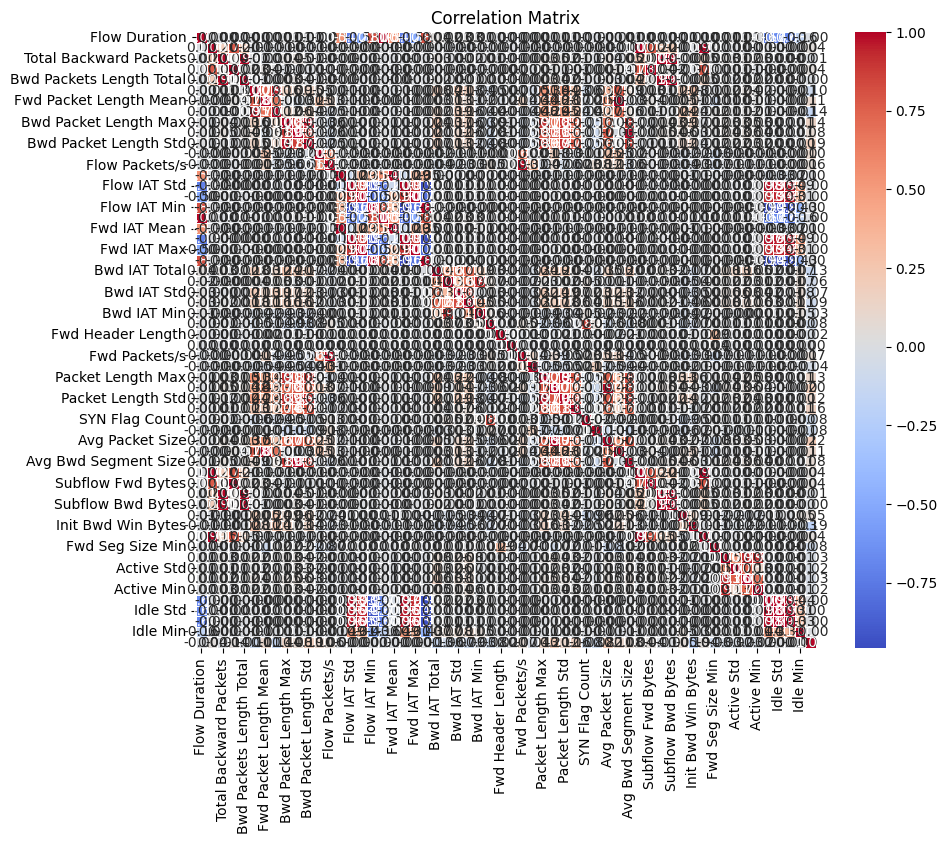

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Encode the 'ClassLabel' column to numerical values for correlation
df['ClassLabel'] = df['ClassLabel'].astype('category').cat.codes

label_encoder = LabelEncoder()
df['ClassLabel'] = label_encoder.fit_transform(df['ClassLabel'])

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Plot the heatmap using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix')
plt.show()

In [13]:
correlation_matrix['ClassLabel'].drop('ClassLabel').sort_values(ascending=False)
# correlation_matrix

Avg Packet Size             0.218567
Packet Length Mean          0.203483
Bwd Packet Length Std       0.187353
Packet Length Variance      0.161060
Bwd Packet Length Max       0.137389
Packet Length Max           0.127886
Packet Length Std           0.116585
Fwd Packet Length Mean      0.107109
Avg Fwd Segment Size        0.107109
Flow Bytes/s                0.100945
Avg Bwd Segment Size        0.079361
Bwd Packet Length Mean      0.079361
Fwd Packets/s               0.069805
Flow Packets/s              0.060499
Init Fwd Win Bytes          0.054144
Subflow Fwd Bytes           0.040179
Fwd Packets Length Total    0.040179
Fwd Act Data Packets        0.038779
Total Fwd Packets           0.038028
Subflow Fwd Packets         0.038028
Bwd Header Length           0.001916
Flow IAT Mean               0.000892
Flow IAT Min                0.000816
Fwd IAT Min                 0.000710
Fwd IAT Mean                0.000348
Idle Std                    0.000075
Idle Max                   -0.000351
I

Keeping highest corealted features

In [14]:
positive_correlation_features = [
    'Avg Packet Size', 'Packet Length Mean', 'Bwd Packet Length Std', 'Packet Length Variance',
    'Bwd Packet Length Max', 'Packet Length Max', 'Packet Length Std', 'Fwd Packet Length Mean',
    'Avg Fwd Segment Size', 'Flow Bytes/s', 'Avg Bwd Segment Size', 'Bwd Packet Length Mean',
    'Fwd Packets/s', 'Flow Packets/s', 'Init Fwd Win Bytes', 'Subflow Fwd Bytes',
    'Fwd Packets Length Total', 'Fwd Act Data Packets', 'Total Fwd Packets', 'Subflow Fwd Packets'
    # Add more features as needed
]
df = df[positive_correlation_features + ['ClassLabel']]
df.shape

(8670130, 21)

In [15]:
df.ClassLabel.value_counts()

ClassLabel
0    7186189
3    1234729
1     145968
2     103244
Name: count, dtype: int64

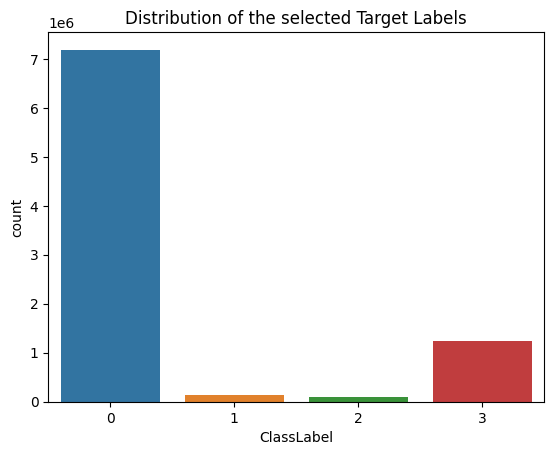

In [16]:
# Distribution of the target variable
sns.countplot(x='ClassLabel', data=df)
plt.title('Distribution of the selected Target Labels')
plt.show()

# undersampling the benign feature beacuse of too many valures

Undersampling involves reducing the number of samples from the majority class(es) so that the dataset becomes more balanced in terms of class representation. This is done by randomly removing instances from the majority class until the number of instances in all classes is equal or more balanced.

In [17]:
# Get the counts of each label
label_counts = df['ClassLabel'].value_counts()

# Set the target count to the count of label 2
target_count = label_counts.min()

# Undersample labels 0 and 1 to the target count
undersampled_df = pd.concat([
    df[df['ClassLabel'] == 0].sample(target_count, replace=False),
    df[df['ClassLabel'] == 1].sample(target_count, replace=False),
    df[df['ClassLabel'] == 2],
    df[df['ClassLabel'] == 3].sample(target_count, replace=False)
], axis=0)

# Shuffle the undersampled DataFrame to mix the labels
undersampled_df = undersampled_df.sample(frac=1).reset_index(drop=True)

In [18]:
undersampled_df.shape

(412976, 21)

In [19]:
label_counts = undersampled_df['ClassLabel'].value_counts()
label_counts

ClassLabel
3    103244
1    103244
2    103244
0    103244
Name: count, dtype: int64

In [20]:
df=undersampled_df

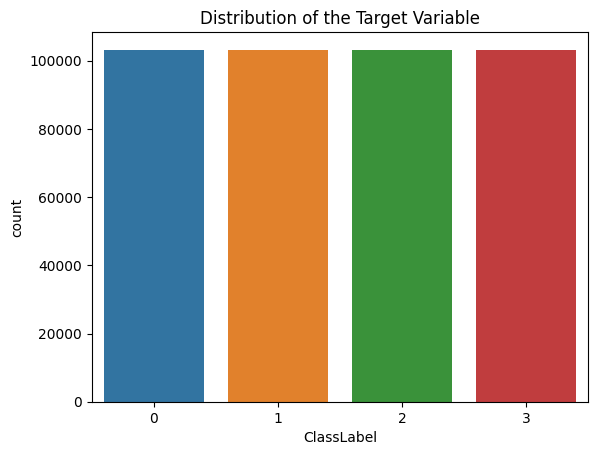

In [21]:
# Distribution of the target variable
sns.countplot(x='ClassLabel', data=df)
plt.title('Distribution of the Target Variable')
plt.show()

In [22]:
!pip install numpy pandas scikit-learn xgboost optuna matplotlib seaborn tensorflow

In [23]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import optuna

# Assuming the dataset is already loaded and preprocessed
X = df.drop('ClassLabel', axis=1)
y = df['ClassLabel']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def objective(trial):
    # Define hyperparameters to be optimized
    params = {
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-4, 1e-1),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': 10,  # Set the number of epochs or boosting rounds here
        'subsample': trial.suggest_uniform('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_uniform('gamma', 0, 1),
        'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-4, 1e2),
        'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-4, 1e2)
    }

    model = XGBClassifier(**params)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    return accuracy

# Create the Optuna study and optimize
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)  # Number of trials for Optuna

# Print the best hyperparameters and accuracy
print("Best hyperparameters: ", study.best_params)
print("Best accuracy: ", study.best_value)

# Train the best model with the entire training data
best_params = study.best_params
best_params['n_estimators'] = 10  # Ensure n_estimators is set to 10
best_model = XGBClassifier(**best_params)
best_model.fit(X_train, y_train)

# Evaluate on the test set
y_pred = best_model.predict(X_test)
print(f'Test Accuracy: {accuracy_score(y_test, y_pred)}')

# Print confusion matrix and classification report
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

[I 2024-09-15 11:46:21,345] A new study created in memory with name: no-name-0e0d2260-238f-424f-a780-4bf7ac724157
/tmp/ipykernel_36/695197482.py:16: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-4, 1e-1),
/tmp/ipykernel_36/695197482.py:19: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample': trial.suggest_uniform('subsample', 0.6, 1.0),
/tmp/ipykernel_36/695197482.py:20: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.6

Best hyperparameters:  {'learning_rate': 0.0006226587278382803, 'max_depth': 9, 'subsample': 0.8274353200004974, 'colsample_bytree': 0.8600690389206466, 'gamma': 0.3830494802366512, 'reg_alpha': 0.0006365827393084614, 'reg_lambda': 0.004990458518098279}
Best accuracy:  0.9957746137827498
Test Accuracy: 0.9957746137827498
Confusion Matrix:
[[20348    44    19    71]
 [   44 20614     0     7]
 [   53     1 20625     2]
 [  106     0     2 20660]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     20482
           1       1.00      1.00      1.00     20665
           2       1.00      1.00      1.00     20681
           3       1.00      0.99      1.00     20768

    accuracy                           1.00     82596
   macro avg       1.00      1.00      1.00     82596
weighted avg       1.00      1.00      1.00     82596



# Main Model

Epoch 1/10
8260/8260 ━━━━━━━━━━━━━━━━━━━━ 206s 24ms/step - accuracy: 0.9176 - loss: 0.2471 - val_accuracy: 0.9678 - val_loss: 0.1051 - learning_rate: 0.0010
Epoch 2/10
8260/8260 ━━━━━━━━━━━━━━━━━━━━ 198s 24ms/step - accuracy: 0.9683 - loss: 0.1012 - val_accuracy: 0.9725 - val_loss: 0.0820 - learning_rate: 0.0010
Epoch 3/10
8260/8260 ━━━━━━━━━━━━━━━━━━━━ 197s 24ms/step - accuracy: 0.9772 - loss: 0.0780 - val_accuracy: 0.9844 - val_loss: 0.0643 - learning_rate: 0.0010
Epoch 4/10
8260/8260 ━━━━━━━━━━━━━━━━━━━━ 201s 24ms/step - accuracy: 0.9790 - loss: 0.0727 - val_accuracy: 0.9855 - val_loss: 0.0526 - learning_rate: 0.0010
Epoch 5/10
8260/8260 ━━━━━━━━━━━━━━━━━━━━ 202s 24ms/step - accuracy: 0.9817 - loss: 0.0655 - val_accuracy: 0.9837 - val_loss: 0.1394 - learning_rate: 0.0010
Epoch 6/10
8260/8260 ━━━━━━━━━━━━━━━━━━━━ 198s 24ms/step - accuracy: 0.9815 - loss: 0.0642 - val_accuracy: 0.9876 - val_loss: 0.0564 - learning_rate: 0.0010
Epoch 7/10
8260/8260 ━━━━━━━━━━━━━━━━━━━━ 198s 24ms/step -

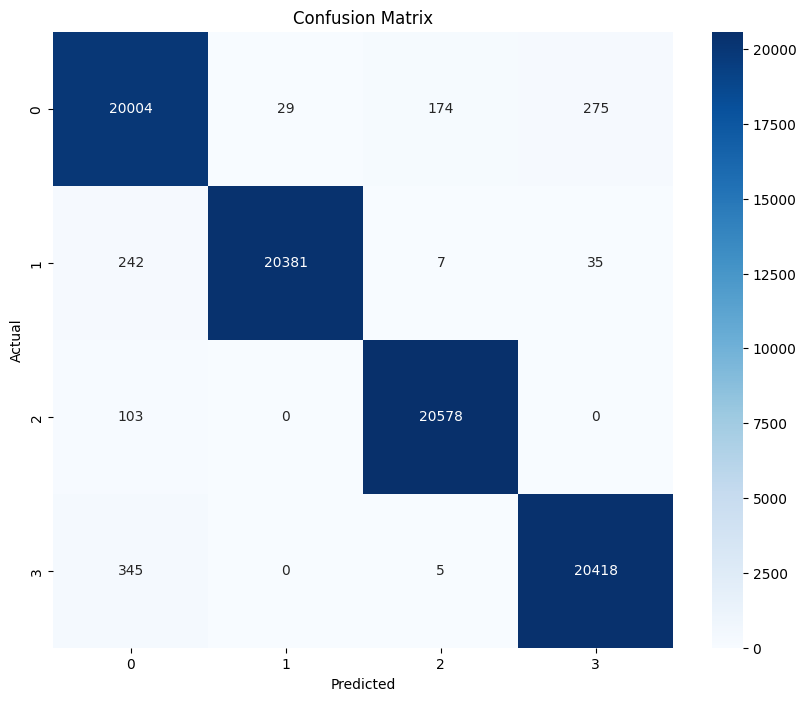

input_layer_6
dense_23
reshape_6
batch_normalization_24
bidirectional_6
dropout_24
conv1d_6
dense_24
batch_normalization_26
batch_normalization_25
attention_layer_6
dropout_25
flatten_6
concatenate_6
dense_25
batch_normalization_27
dropout_27
dense_26


ValueError: No such layer: attention_layer_5. Existing layers are: ['input_layer_6', 'dense_23', 'reshape_6', 'batch_normalization_24', 'bidirectional_6', 'dropout_24', 'conv1d_6', 'dense_24', 'batch_normalization_26', 'batch_normalization_25', 'attention_layer_6', 'dropout_25', 'flatten_6', 'concatenate_6', 'dense_25', 'batch_normalization_27', 'dropout_27', 'dense_26'].

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.layers import MultiHeadAttention, Bidirectional, LSTM

# Load and preprocess data (assuming df is already loaded)
df.rename(columns={'6': 'ClassLabel'}, inplace=True)

# Prepare features and target variable
X = df.drop('ClassLabel', axis=1).values
y = df['ClassLabel'].values

# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define custom attention layer (Multi-Head Attention)
class AttentionLayer(layers.Layer):
    def __init__(self, units, num_heads=8):
        super(AttentionLayer, self).__init__()
        self.mha = MultiHeadAttention(num_heads=num_heads, key_dim=units)

    def call(self, inputs):
        attention_output = self.mha(inputs, inputs)
        return attention_output

# Define the model
def build_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    # First branch: Dense layers
    x1 = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.Dropout(0.3)(x1)
    x1 = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x1)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.Dropout(0.3)(x1)

    # Second branch: Attention mechanism
    x2 = layers.Reshape((input_shape[0], 1))(inputs)
    x2 = Bidirectional(LSTM(64, return_sequences=True))(x2)  # Bidirectional LSTM
    x2 = layers.Conv1D(filters=32, kernel_size=3, padding='same', activation='relu')(x2)
    x2 = layers.BatchNormalization()(x2)
    attention_output = AttentionLayer(32)(x2)
    x2 = layers.Flatten()(attention_output)

    # Concatenate both branches
    x = layers.Concatenate()([x1, x2])

    # Final dense layers
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

# Build and compile the model
model = build_model(input_shape=(X_train.shape[1],), num_classes=len(np.unique(y)))

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Define callbacks
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[reduce_lr, early_stopping]
)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {accuracy:.4f}")

# Classification report and confusion matrix
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# List all layer names to find the attention layer
for layer in model.layers:
    print(layer.name)

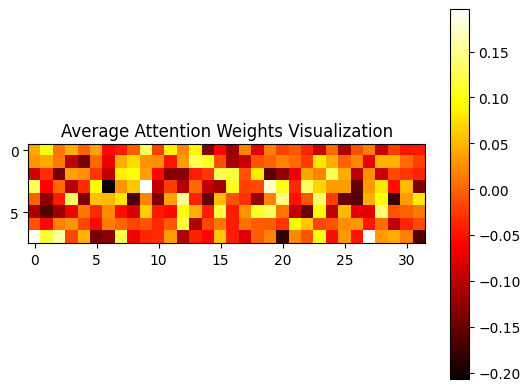

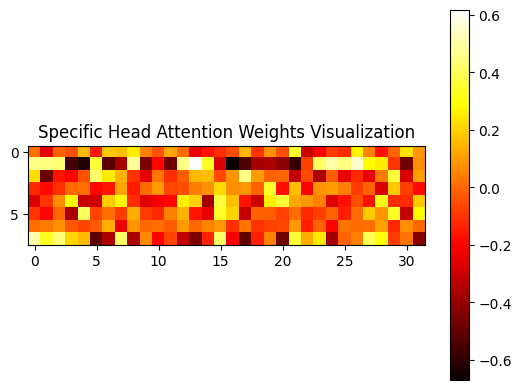

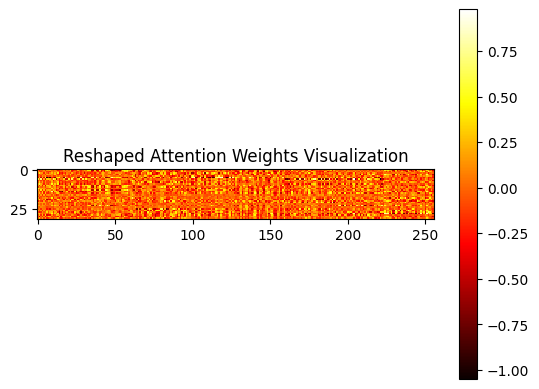

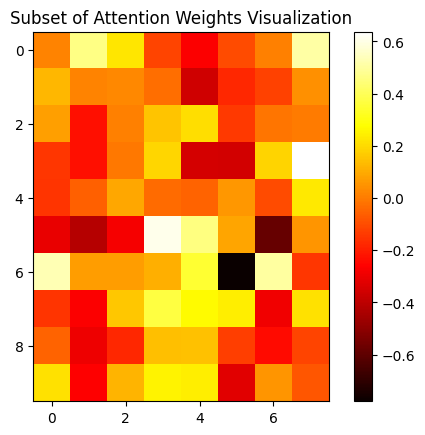

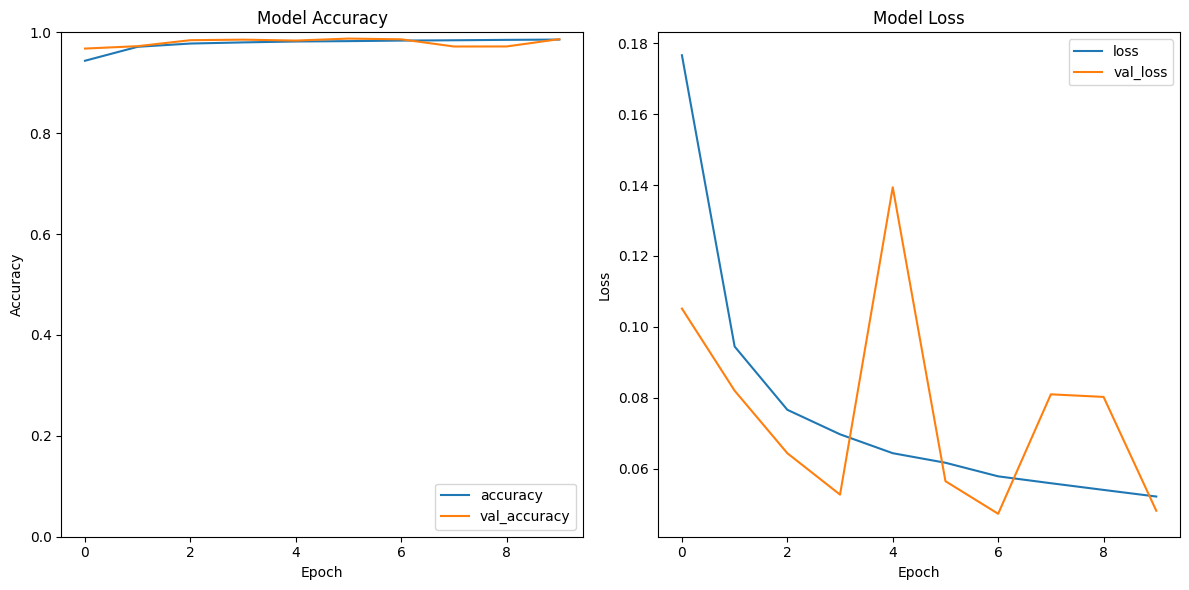

In [36]:
# Visualize attention weights
try:
    attention_layer = model.get_layer('attention_layer_6')
    attention_weights = attention_layer.get_weights()

    if attention_weights:
        # Option 1: Average over the heads
        average_attention_weights = np.mean(attention_weights[0], axis=0)
        plt.imshow(average_attention_weights, cmap='hot', interpolation='nearest')
        plt.colorbar()
        plt.title('Average Attention Weights Visualization')
        plt.show()

        # Option 2: Select a specific head (e.g., head 0)
        specific_head_attention_weights = attention_weights[0][0]
        plt.imshow(specific_head_attention_weights, cmap='hot', interpolation='nearest')
        plt.colorbar()
        plt.title('Specific Head Attention Weights Visualization')
        plt.show()

        # Option 3: Reshape the data if applicable
        reshaped_attention_weights = np.reshape(attention_weights[0], (attention_weights[0].shape[0], -1))
        plt.imshow(reshaped_attention_weights, cmap='hot', interpolation='nearest')
        plt.colorbar()
        plt.title('Reshaped Attention Weights Visualization')
        plt.show()

        # Option 4: Visualize a subset
        subset_attention_weights = attention_weights[0][:10, :10, :]
        plt.imshow(subset_attention_weights[:, :, 0], cmap='hot', interpolation='nearest')
        plt.colorbar()
        plt.title('Subset of Attention Weights Visualization')
        plt.show()

except ValueError as e:
    print(f"Error: {e}")

# Plot training history
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.title('Model Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()